In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import mne

# Reaction Times and Distribution of Oddballs

In [2]:
df = pd.read_csv('sub-001_events.csv')
df

,Block,Trial_Num,Tone_Num,Condition,onset_time,ISI,n_oddballs,correct_answer,response,response_correct,RT
0,1,1,1,standard,148.297494,0.7390,1,NaN,NaN,NaN,NaN
1,1,1,2,standard,149.460283,0.7336,1,NaN,NaN,NaN,NaN
2,1,1,3,standard,150.611085,0.8050,1,NaN,NaN,NaN,NaN
3,1,1,4,standard,151.835943,0.8848,1,NaN,NaN,NaN,NaN
4,1,1,5,deviant,153.144916,0.8358,1,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2195,2,100,7,deviant,3165.987411,0.7096,5,y,NaN,NaN,NaN
2196,2,100,8,deviant,3167.121178,0.7692,5,y,NaN,NaN,NaN
2197,2,100,9,standard,3168.321587,0.7747,5,y,NaN,NaN,NaN
2198,2,100,10,deviant,3169.513699,0.8070,5,y,NaN,NaN,NaN


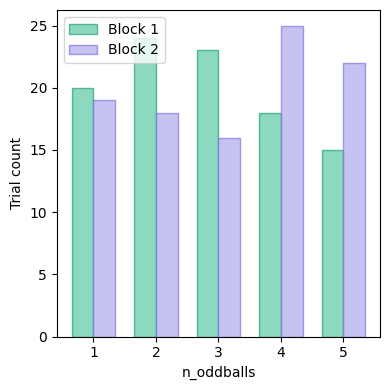

In [3]:
# one row per trial
trials = df.dropna(subset=['Trial_Num', 'n_oddballs']).drop_duplicates(subset=['Block', 'Trial_Num'])

b1 = trials[trials['Block'] == 1]['n_oddballs'].value_counts().sort_index()
b2 = trials[trials['Block'] == 2]['n_oddballs'].value_counts().sort_index()

x = [1, 2, 3, 4, 5]
width = 0.35

fig, ax = plt.subplots(figsize=(4, 4))
ax.bar([i - width/2 for i in x], b1, width=width, label='Block 1', color='#5DCAA5', edgecolor='#1D9E75', alpha = 0.7)
ax.bar([i + width/2 for i in x], b2, width=width, label='Block 2', color='#AFA9EC', edgecolor='#7F77DD', alpha = 0.7)

ax.set_xlabel('n_oddballs')
ax.set_ylabel('Trial count')
ax.set_xticks(x)
ax.legend()
plt.tight_layout()
plt.show()

Overall accuracy: 96.0% correct (96/100 trials)


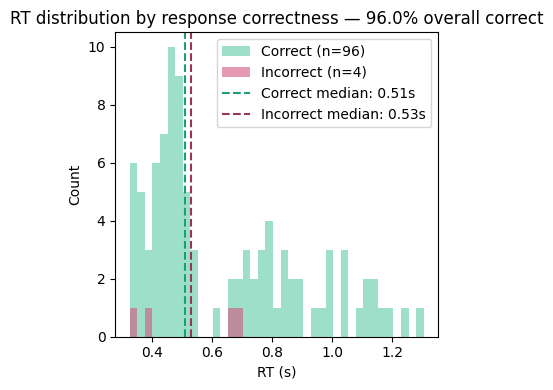

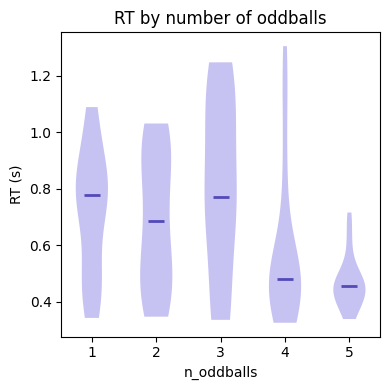

In [4]:
# Filter to response rows only
resp = df[df['Condition'] == 'response'].copy()
resp['RT'] = pd.to_numeric(resp['RT'], errors='coerce')
resp['response_correct'] = pd.to_numeric(resp['response_correct'], errors='coerce')
resp['n_oddballs'] = pd.to_numeric(resp['n_oddballs'], errors='coerce')
resp = resp.dropna(subset=['RT', 'response_correct'])

pct_correct = resp['response_correct'].mean() * 100
print(f"Overall accuracy: {pct_correct:.1f}% correct ({int(resp['response_correct'].sum())}/{len(resp)} trials)")

correct_rt = resp[resp['response_correct'] == 1]['RT']
incorrect_rt = resp[resp['response_correct'] == 0]['RT']

# --- Plot 1: RT distribution by correctness ---
fig, ax = plt.subplots(figsize=(4, 4))
bins = np.linspace(resp['RT'].min(), resp['RT'].max(), 40)
ax.hist(correct_rt, bins=bins, alpha=0.6, label=f'Correct (n={len(correct_rt)})', color='#5DCAA5', edgecolor='none')
ax.hist(incorrect_rt, bins=bins, alpha=0.6, label=f'Incorrect (n={len(incorrect_rt)})', color='#D4537E', edgecolor='none')
ax.axvline(correct_rt.median(), color='#1D9E75', linestyle='--', linewidth=1.5, label=f'Correct median: {correct_rt.median():.2f}s')
ax.axvline(incorrect_rt.median(), color='#993556', linestyle='--', linewidth=1.5, label=f'Incorrect median: {incorrect_rt.median():.2f}s')
ax.set_xlabel('RT (s)')
ax.set_ylabel('Count')
ax.set_title(f'RT distribution by response correctness — {pct_correct:.1f}% overall correct')
ax.legend()
plt.tight_layout()
plt.show()

# --- Plot 2: RT by n_oddballs ---
fig, ax = plt.subplots(figsize=(4, 4))
oddball_levels = sorted(resp['n_oddballs'].dropna().unique())
data_by_oddball = [resp[resp['n_oddballs'] == n]['RT'].values for n in oddball_levels]

parts = ax.violinplot(data_by_oddball, positions=oddball_levels, showmedians=True, showextrema=False)
for pc in parts['bodies']:
    pc.set_facecolor('#AFA9EC')
    pc.set_alpha(0.7)
parts['cmedians'].set_color('#534AB7')
parts['cmedians'].set_linewidth(2)

ax.set_xlabel('n_oddballs')
ax.set_ylabel('RT (s)')
ax.set_xticks(oddball_levels)
ax.set_title('RT by number of oddballs')

plt.tight_layout()
plt.show()

# Eyetracking

In [4]:
raw = mne.io.read_raw_eyelink('recording.asc')
df = raw.to_data_frame()
annot_df = pd.DataFrame({
    'onset': raw.annotations.onset,
    'duration': raw.annotations.duration,
    'description': raw.annotations.description
})

# load behavioral data
beh = pd.read_csv('sub-001_events.csv')
beh = beh[beh['Condition'].isin(['standard', 'deviant'])].copy()
beh['onset_time'] = pd.to_numeric(beh['onset_time'], errors='coerce')
beh['Block'] = pd.to_numeric(beh['Block'], errors='coerce')

# anchor: EXPERIMENT_START in ET time, and the first tone onset in behavioral time
et_start = annot_df[annot_df['description'] == 'EXPERIMENT_START']['onset'].values[0]
beh_start = beh['onset_time'].min()

# compute each tone's onset in ET time
beh['et_time'] = et_start + (beh['onset_time'] - beh_start)

print("ET experiment start (s):", et_start)
print("First behavioral onset (s):", beh_start)
print("Example mapped ET onsets:")
print(beh[['Block', 'Condition', 'onset_time', 'et_time']].head(10))

Loading /content/recording.asc
Pixel coordinate data detected.Pass `scalings=dict(eyegaze=1e3)` when using plot method to make traces more legible.
Pupil-size area detected.
No button events found in this file.
ET experiment start (s): 0.105
First behavioral onset (s): 148.297494
Example mapped ET onsets:
   Block Condition  onset_time    et_time
0      1  standard  148.297494   0.105000
1      1  standard  149.460283   1.267789
2      1  standard  150.611085   2.418591
3      1  standard  151.835943   3.643449
4      1   deviant  153.144916   4.952422
5      1  standard  154.395354   6.202860
6      1  standard  155.720879   7.528385
7      1  standard  156.921165   8.728671
8      1  standard  158.071541   9.879047
9      1  standard  159.355467  11.162973


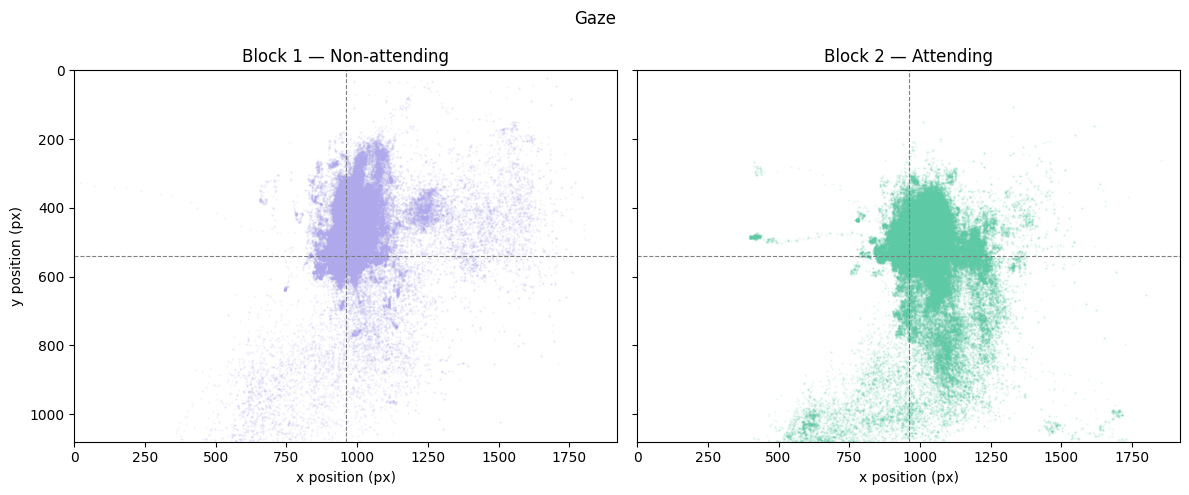

In [22]:
# --- Plot 1: Gaze in x-y space, split by block ---

# split gaze by block using et_time ranges
block1_times = beh[beh['Block'] == 1]['et_time']
block2_times = beh[beh['Block'] == 2]['et_time']

block1_start, block1_end = block1_times.min(), block1_times.max()
block2_start, block2_end = block2_times.min(), block2_times.max()

gaze_b1 = df[(df['time'] >= block1_start) & (df['time'] <= block1_end)]
gaze_b2 = df[(df['time'] >= block2_start) & (df['time'] <= block2_end)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, gaze, title in zip(axes,
                            [gaze_b1, gaze_b2],
                            ['Block 1 — Non-attending', 'Block 2 — Attending']):
    ax.scatter(gaze['xpos_right'], gaze['ypos_right'],
               s=0.5, alpha=0.1, color='#5DCAA5' if 'Attending' in title else '#AFA9EC',
               rasterized=True)
    ax.axvline(960, color='gray', linestyle='--', linewidth=0.8)
    ax.axhline(540, color='gray', linestyle='--', linewidth=0.8)
    ax.set_xlim(0, 1920)
    ax.set_ylim(1080, 0)  # flip y to match screen coordinates
    ax.set_xlabel('x position (px)')
    ax.set_title(title)

axes[0].set_ylabel('y position (px)')
fig.suptitle('Gaze')
plt.tight_layout()
plt.show()


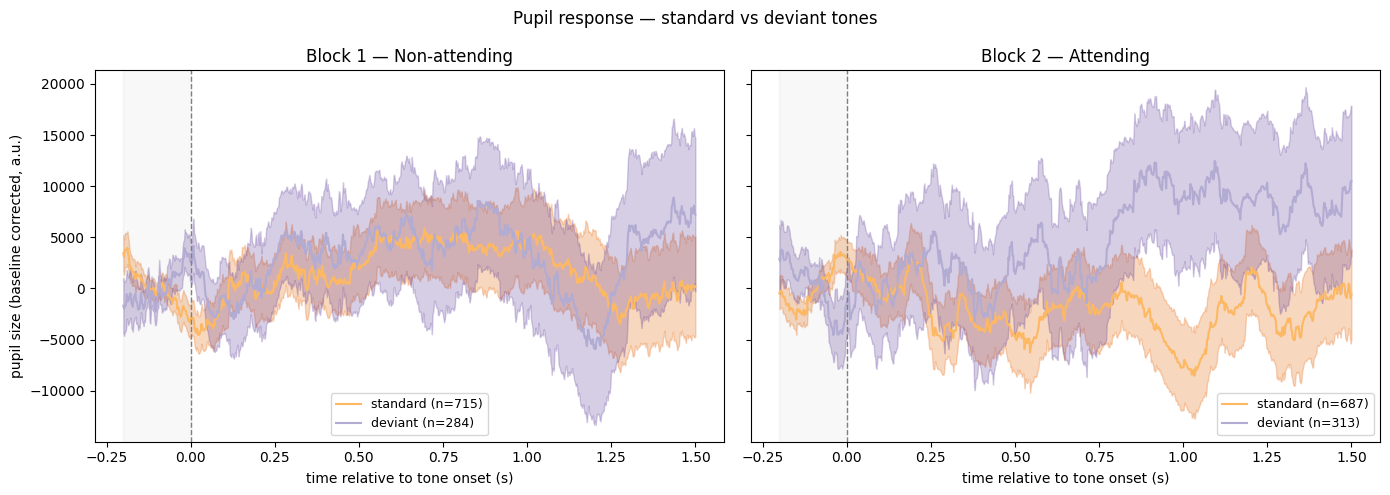

In [16]:
# --- Plot 2: Pupil responses split into attending / non-attending subplots ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

block_info = [
    (1, 'Block 1 — Non-attending',  {'standard': ('#e66101', '#fdb863'), 'deviant': ('#5e3c99', '#b2abd2')}),
    (2, 'Block 2 — Attending', {'standard': ('#e66101', '#fdb863'), 'deviant': ('#5e3c99', '#b2abd2')}),
]

for ax, (block_num, title, colors) in zip(axes, block_info):
    for cond, (fill_color, line_color) in colors.items():
        mask = (beh['Block'] == block_num) & (beh['Condition'] == cond)
        onsets = beh[mask]['et_time'].values
        epochs = extract_epochs(onsets, pupil, times, EPOCH_START, EPOCH_END)
        if len(epochs) == 0:
            print(f'No epochs for block {block_num} {cond}')
            continue
        mean = epochs.mean(axis=0)
        sem  = epochs.std(axis=0) / np.sqrt(len(epochs))
        ax.plot(epoch_time, mean, color=line_color, label=f'{cond} (n={len(epochs)})')
        ax.fill_between(epoch_time, mean - sem, mean + sem, alpha=0.25, color=fill_color)

    ax.axvline(0, color='gray', linestyle='--', linewidth=1)
    ax.axvspan(EPOCH_START, 0, alpha=0.05, color='gray')
    ax.set_xlabel('time relative to tone onset (s)')
    ax.set_title(title)
    ax.legend(fontsize=9)

axes[0].set_ylabel('pupil size (baseline corrected, a.u.)')
fig.suptitle('Pupil response — standard vs deviant tones')
plt.tight_layout()
plt.show()

## Are these differences across conditions significant?

In [20]:
from mne.stats import permutation_cluster_1samp_test

for block_num, block_label in [(1, 'Non-attending'), (2, 'Attending')]:
    std_epochs = extract_epochs(beh[(beh['Block']==block_num) & (beh['Condition']=='standard')]['et_time'].values, pupil, times, EPOCH_START, EPOCH_END)
    dev_epochs = extract_epochs(beh[(beh['Block']==block_num) & (beh['Condition']=='deviant')]['et_time'].values, pupil, times, EPOCH_START, EPOCH_END)

    n = min(len(std_epochs), len(dev_epochs))
    diff = dev_epochs[:n] - std_epochs[:n]

    t_obs, clusters, pvals, _ = permutation_cluster_1samp_test(
        diff, n_permutations=1000, tail=0, verbose=False
    )

    print(f"\n{block_label} — significant clusters (deviant - standard):")
    found = False
    for cluster, pval in zip(clusters, pvals):
        if pval < 0.05:
            times_in_cluster = epoch_time[cluster[0]]
            print(f"  p={pval:.4f}, {times_in_cluster.min():.2f}s to {times_in_cluster.max():.2f}s")
            found = True
    if not found:
        print("  No significant clusters")


Non-attending — significant clusters (deviant - standard):
  No significant clusters

Attending — significant clusters (deviant - standard):
  No significant clusters


In [21]:
from scipy import stats

window = (epoch_time >= 0.5) & (epoch_time <= 1.5)

for block_num, block_label in [(1, 'Attending'), (2, 'Non-attending')]:
    std_epochs = extract_epochs(beh[(beh['Block']==block_num) & (beh['Condition']=='standard')]['et_time'].values, pupil, times, EPOCH_START, EPOCH_END)
    dev_epochs = extract_epochs(beh[(beh['Block']==block_num) & (beh['Condition']=='deviant')]['et_time'].values, pupil, times, EPOCH_START, EPOCH_END)

    std_amp = std_epochs[:, window].mean(axis=1)
    dev_amp = dev_epochs[:, window].mean(axis=1)

    u, p = stats.mannwhitneyu(std_amp, dev_amp, alternative='two-sided')
    print(f"{block_label}: standard mean={std_amp.mean():.1f}, deviant mean={dev_amp.mean():.1f}, U={u:.1f}, p={p:.4f}")

Attending: standard mean=2449.7, deviant mean=3593.8, U=100397.0, p=0.7831
Non-attending: standard mean=-2625.7, deviant mean=7053.0, U=101539.0, p=0.1582
